# 🔋 BAB 4: Analisis Parameter ECM & Implementasi EKF pada Baterai LiFePO4
**Dataset:** `2026-3-4-12-23-29-EBC-A40L-1-1.csv`
**Kapasitas Nominal:** 22 Ah
**Metodologi:** Modified HPPC (Hybrid Pulse Power Characterization) Sesuai Standar FreedomCAR.

---
## 1️⃣ DATA IMPORT & PREPROCESSING
Tahap pertama dalam analisis ini adalah memuat data mentah (*raw data*) yang direkam oleh instrumen ZKETECH EBC-A40L. 

**Struktur Data:**
Data deret waktu (*time-series*) yang dihasilkan mengandung tiga parameter utama:
1. `Time(S)`: Waktu pengujian dalam detik.
2. `Cur(A)`: Arus pembebanan (A). Nilai positif menunjukkan *discharge*.
3. `Vol(V)`: Tegangan terminal baterai (V).

**Segmentasi Data:**
Pengujian HPPC terdiri dari beberapa langkah berulang (*loop*). Setiap siklus dirancang untuk menurunkan State of Charge (SOC) sebesar $\approx 10\%$. Segmentasi data (kapan pulsa terjadi dan kapan baterai beristirahat) dideteksi secara otomatis menggunakan algoritma berbasis transisi arus ($\Delta I$).

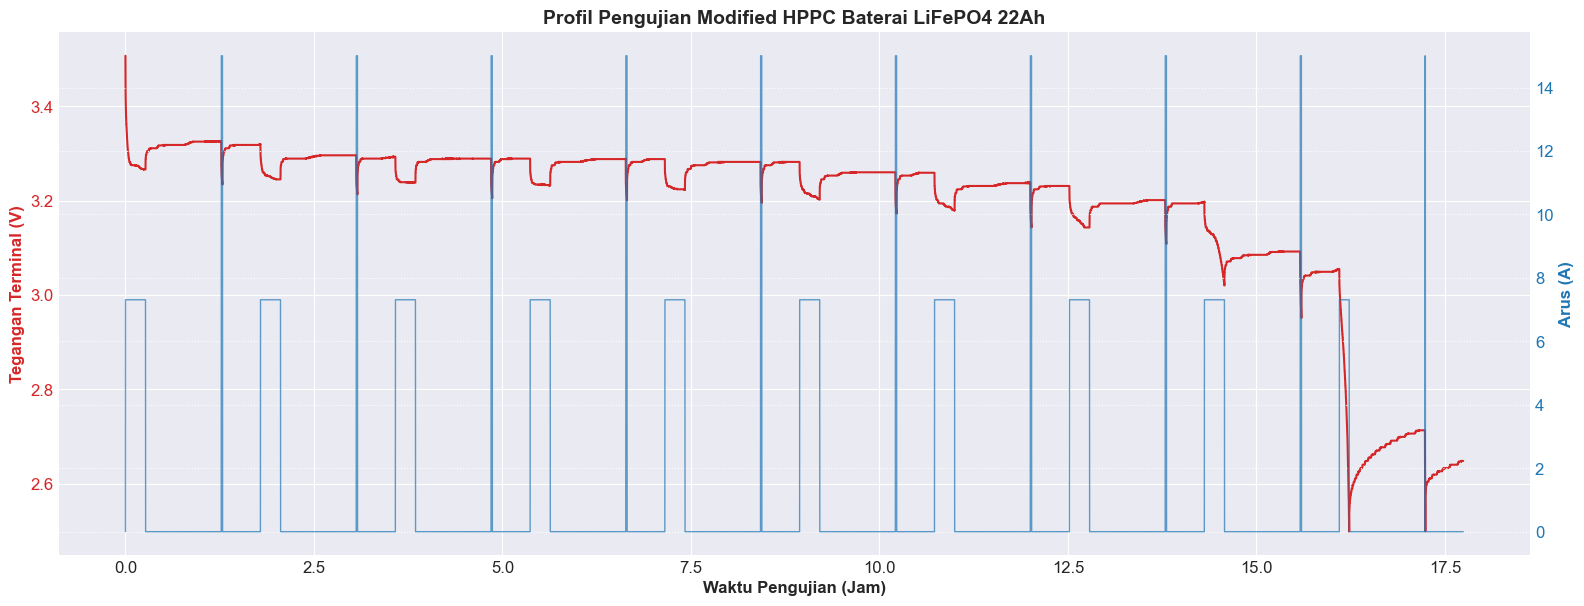

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Konfigurasi Tampilan Plot
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

# =========================================================
# 1. IMPORT DATASET
# =========================================================
def load_zke_data(filepath):
    skip_rows = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if "Time(S)" in line:
                skip_rows = i
                break
    df = pd.read_csv(filepath, skiprows=skip_rows)
    df.columns = [col.strip() for col in df.columns]
    return df

file_name = "hppc modified.csv"
df = load_zke_data(file_name)

# Hitung Delta Time (dt)
df['dt'] = df['Time(S)'].diff().fillna(0)

# =========================================================
# 2. VISUALISASI PROFIL DATA MENTAH
# =========================================================
fig, ax1 = plt.subplots(figsize=(16, 6))

waktu_jam = df['Time(S)'] / 3600.0

color_v = 'tab:red'
ax1.set_xlabel('Waktu Pengujian (Jam)', fontweight='bold')
ax1.set_ylabel('Tegangan Terminal (V)', color=color_v, fontweight='bold')
ax1.plot(waktu_jam, df['Vol(V)'], color=color_v, linewidth=1.5, label='Voltage (V)')
ax1.tick_params(axis='y', labelcolor=color_v)

ax2 = ax1.twinx()  
color_c = 'tab:blue'
ax2.set_ylabel('Arus (A)', color=color_c, fontweight='bold')
ax2.plot(waktu_jam, df['Cur(A)'], color=color_c, linewidth=1, alpha=0.7, label='Current (A)')
ax2.tick_params(axis='y', labelcolor=color_c)

fig.tight_layout()
plt.title('Profil Pengujian Modified HPPC Baterai LiFePO4 22Ah', fontweight='bold', fontsize=14)
plt.grid(True, linestyle=':')
plt.show()

---
## 2️⃣ PERHITUNGAN SOC (COULOMB COUNTING)

**Rumus Estimasi (Ampere-Hour Integration):**
Metode standar untuk menghitung kapasitas yang tersisa adalah integrasi arus terhadap waktu:
$$SOC(t) = SOC(t_0) - \int_{t_0}^{t} \frac{I(\tau)}{3600 \cdot Q_{nom}} d\tau$$
Dimana $Q_{nom}$ adalah kapasitas baterai (22 Ah).

**Kelemahan Coulomb Counting:**
Metode ini bersifat *open-loop* (tanpa umpan balik). Setiap kesalahan kecil (*noise*) pada sensor arus akan terakumulasi seiring waktu (*accumulated drift error*). Selain itu, metode ini membutuhkan nilai $SOC(t_0)$ yang absolut, yang sulit diketahui jika sistem sempat kehilangan daya (*reboot*). Oleh karena itu, *mapping OCV* diperlukan sebagai referensi *closed-loop*.

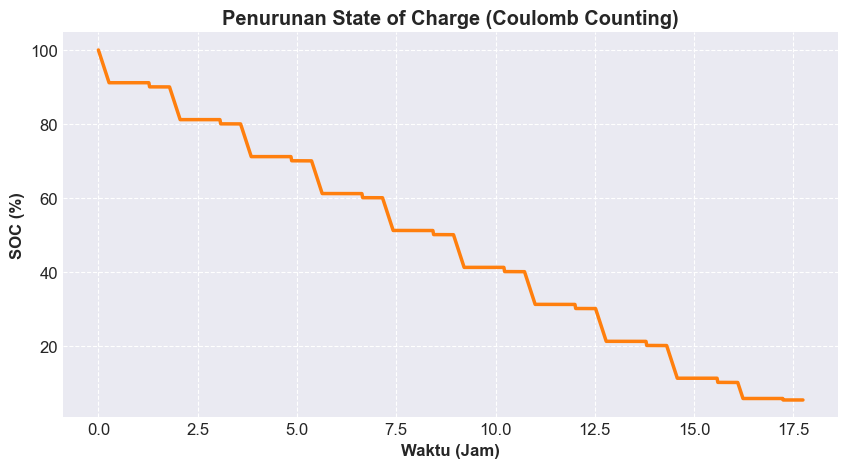

In [2]:
# =========================================================
# PERHITUNGAN SOC DENGAN COULOMB COUNTING
# =========================================================
Q_nominal = 22.0  # Kapasitas Baterai (Ah)
SOC_awal = 1.0    # Asumsi baterai dimulai dari 100%

# Akumulasi Ah discharged
df['Ah_Discharged'] = (df['Cur(A)'] * df['dt']).cumsum() / 3600.0

# Perhitungan SOC CC (%)
df['SOC_CC'] = (SOC_awal - (df['Ah_Discharged'] / Q_nominal))

plt.figure(figsize=(10, 5))
plt.plot(df['Time(S)'] / 3600.0, df['SOC_CC'] * 100, color='tab:orange', linewidth=2.5)
plt.title('Penurunan State of Charge (Coulomb Counting)', fontweight='bold')
plt.xlabel('Waktu (Jam)', fontweight='bold')
plt.ylabel('SOC (%)', fontweight='bold')
plt.grid(True, linestyle='--')
plt.show()

---
## 3️⃣ EKSTRAKSI KURVA SOC-OCV (LOOK-UP TABLE)

**Definisi OCV:**
*Open Circuit Voltage* (OCV) adalah tegangan murni baterai saat berada dalam kesetimbangan termodinamika (tidak ada aliran arus dan efek polarisasi telah hilang). 

**Karakteristik LiFePO4 & Fenomena Runge:**
Baterai *Lithium Iron Phosphate* (LiFePO4) terkenal dengan fase *plateau* tegangannya yang sangat datar di rentang SOC 20% - 90%. Jika kita memaksakan regresi polinomial orde tinggi pada data ini, akan terjadi **Fenomena Runge** (kurva berosilasi/bergelombang secara tidak wajar di antara titik-titik data). Hal ini sangat berbahaya bagi EKF karena akan menghasilkan nilai turunan (Jacobian) yang salah kaprah.

**Pendekatan Interpolasi Linear (LUT):**
Sebagai solusi standar industri, kita menggunakan *Look-Up Table* (LUT) berbasis interpolasi linear (`scipy.interpolate.interp1d`). Nilai OCV diambil di akhir masa relaksasi 60 menit tepat sebelum pulsa 15A dieksekusi, kemudian diinterpolasi untuk membentuk kurva $OCV(SOC)$ yang stabil dan tidak bergelombang.

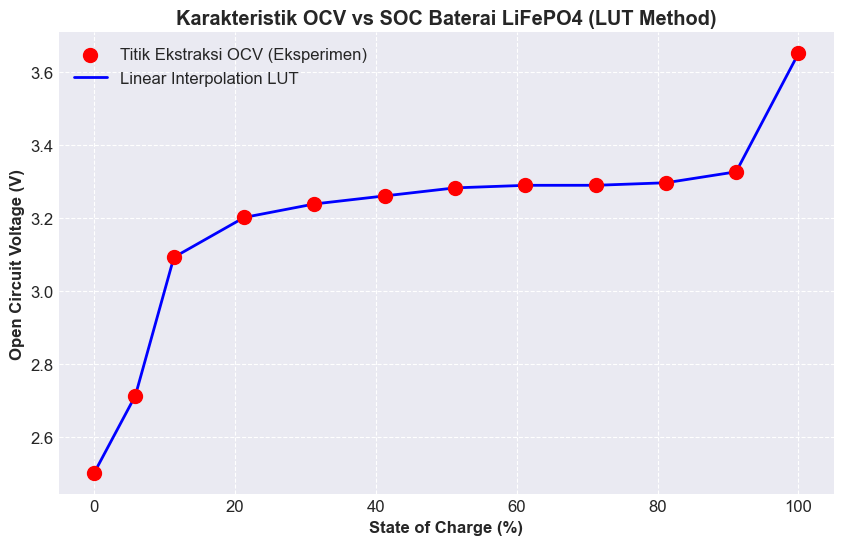

✅ Fungsi Look-Up Table OCV (f_OCV_LUT) berhasil dibuat!


In [3]:
from scipy.interpolate import interp1d

# =========================================================
# DETEKSI PULSA DAN EKSTRAKSI OCV (LUT METHOD)
# =========================================================
# Deteksi Pulsa 15A
is_pulse = (df['Cur(A)'] > 14.0) & (df['Cur(A)'] < 16.0)
pulse_starts = df.index[is_pulse.astype(int).diff() == 1].tolist()
pulse_ends = df.index[is_pulse.astype(int).diff() == -1].tolist()

ocv_points = []
soc_points = []

# Ambil tegangan dan SOC tepat sebelum setiap pulsa 15A (Akhir dari Rest 60 menit)
for idx in pulse_starts:
    ocv = df['Vol(V)'].iloc[idx - 1]
    soc = df['SOC_CC'].iloc[idx - 1]
    ocv_points.append(ocv)
    soc_points.append(soc)

# Tambahkan asumsi titik absolut 0% (2.5V) dan 100% (3.65V jika tidak ada) untuk pengaman ekstrapolasi
if soc_points[-1] > 0.05:
    soc_points.append(0.0)
    ocv_points.append(2.50)
if soc_points[0] < 0.98:
    soc_points.append(1.0)
    ocv_points.append(3.65)

# Susun ke DataFrame dan urutkan berdasarkan SOC (wajib untuk interp1d)
df_ocv = pd.DataFrame({'SOC': soc_points, 'OCV': ocv_points}).sort_values(by='SOC')

# Buat Fungsi Look-Up Table (Interpolasi Linear)
f_OCV_LUT = interp1d(df_ocv['SOC'], df_ocv['OCV'], kind='linear', fill_value='extrapolate')

# Generate kurva kontinu untuk visualisasi
soc_axis = np.linspace(0, 1, 200)
ocv_fit = f_OCV_LUT(soc_axis)

plt.figure(figsize=(10, 6))
plt.scatter(df_ocv['SOC']*100, df_ocv['OCV'], color='red', s=100, zorder=5, label='Titik Ekstraksi OCV (Eksperimen)')
plt.plot(soc_axis*100, ocv_fit, color='blue', linewidth=2, label='Linear Interpolation LUT')
plt.title('Karakteristik OCV vs SOC Baterai LiFePO4 (LUT Method)', fontweight='bold')
plt.xlabel('State of Charge (%)', fontweight='bold')
plt.ylabel('Open Circuit Voltage (V)', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

print("✅ Fungsi Look-Up Table OCV (f_OCV_LUT) berhasil dibuat!")

---
## 4️⃣ EKSTRAKSI PARAMETER RESISTANSI OHMIK ($R_0$)

**Interpretasi Fisik:**
Hambatan ohmik ($R_0$) merepresentasikan resistansi internal murni yang berasal dari material elektroda, elektrolit, dan kontak terminal. Sifatnya merespons arus secara instan.

**Metode Ekstraksi:**
Nilai ini dihitung berdasarkan *voltage drop* ($V_{drop}$) yang terjadi seketika (dalam orde milidetik hingga detik pertama) saat arus pulsa diterapkan.
$$R_0 = \frac{OCV - V_{pulse\_start}}{I_{pulse}}$$

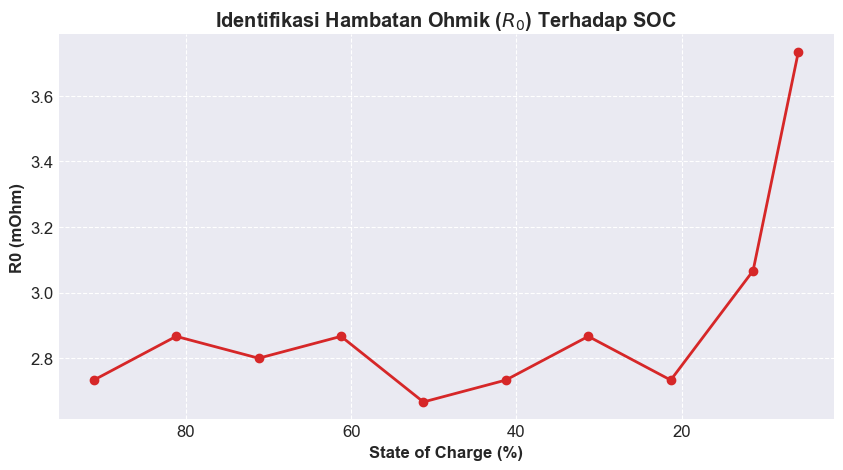

In [4]:
# =========================================================
# EKSTRAKSI R0
# =========================================================
R0_list = []
soc_r0_list = []

for idx in pulse_starts:
    ocv = df['Vol(V)'].iloc[idx - 1]
    v_drop = df['Vol(V)'].iloc[idx] # Tegangan di detik pertama pulsa
    i_pulse = df['Cur(A)'].iloc[idx]
    
    r0 = (ocv - v_drop) / i_pulse
    
    R0_list.append(r0)
    soc_r0_list.append(df['SOC_CC'].iloc[idx - 1])

# Simpan ke DataFrame
df_params = pd.DataFrame({'SOC': np.array(soc_r0_list), 'R0 (Ohm)': R0_list})

plt.figure(figsize=(10, 5))
plt.plot(df_params['SOC']*100, df_params['R0 (Ohm)'] * 1000, marker='o', color='tab:red', linewidth=2)
plt.title('Identifikasi Hambatan Ohmik ($R_0$) Terhadap SOC', fontweight='bold')
plt.xlabel('State of Charge (%)', fontweight='bold')
plt.ylabel('R0 (mOhm)', fontweight='bold')
plt.gca().invert_xaxis()
plt.grid(True, linestyle='--')
plt.show()

---
## 5️⃣ EKSTRAKSI $R_1$ DAN $C_1$ (MODEL ECM 1RC)

**Penjelasan Model 1RC:**
Setelah pulsa arus dihilangkan, tegangan baterai tidak langsung kembali ke nilai OCV, melainkan pulih secara eksponensial. Hal ini dimodelkan menggunakan rangkaian RC paralel.

**Optimalisasi Curve Fitting (TRF Method):**
Pada SOC yang sangat rendah (misal < 10%), kurva relaksasi seringkali curam dan *noisy*. Fungsi optimasi standar sering gagal konvergen di area ini. Untuk mengatasinya, kita menggunakan algoritma `method='trf'` (*Trust Region Reflective*) dengan batas bawah dan atas (*bounds*) yang tegas secara fisik. 
Tebakan awal ($p_0$) juga dibuat dinamis berdasarkan selisih tegangan aktual di detik pertama relaksasi, sehingga memastikan algoritma selalu menemukan titik konvergensi yang tepat.

**Formulasi Relaksasi Matematis:**
$$V(t) = OCV - V_{p1} \cdot e^{-\frac{t}{\tau}}$$
Dimana $R_1 = \frac{V_{p1}}{I_{pulse}}$ dan $C_1 = \frac{\tau}{R_1}$.

⏳ Memulai optimasi curve_fit untuk parameter RC...


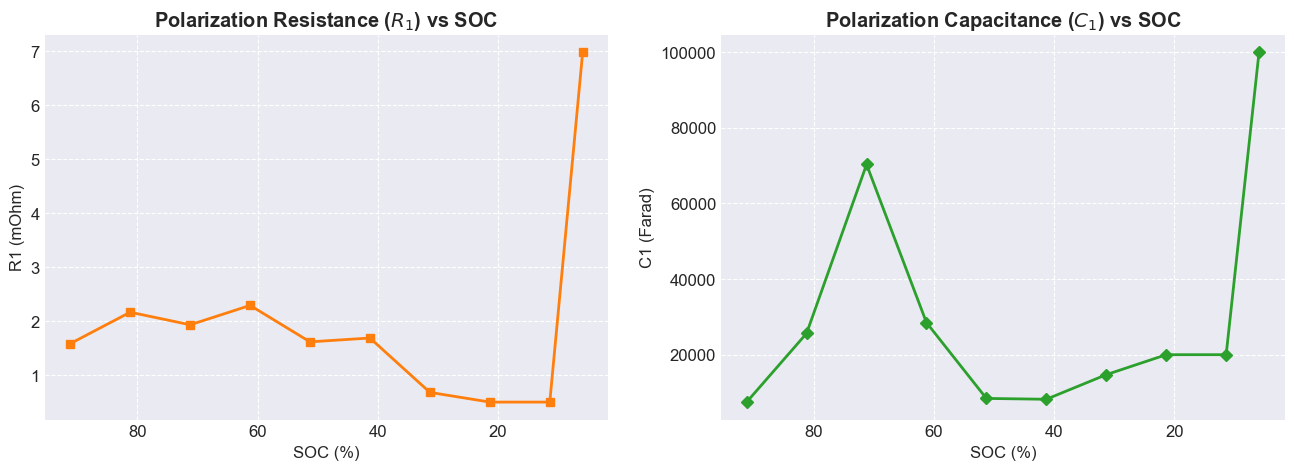

✅ Parameter ECM fisik telah dibatasi dengan wajar!


In [5]:
# =========================================================
# EKSTRAKSI R1 DAN C1 (OPTIMIZED CURVE FITTING WITH PHYSICAL BOUNDS)
# =========================================================
R1_list = []
C1_list = []

print("⏳ Memulai optimasi curve_fit untuk parameter RC...")

for i in range(min(len(pulse_starts), len(pulse_ends))):
    start_pulse = pulse_starts[i]
    end_pulse = pulse_ends[i]
    
    i_pulse = abs(df['Cur(A)'].iloc[start_pulse])
    
    if i + 1 < len(pulse_starts):
        end_relax = pulse_starts[i+1] - 1
    else:
        end_relax = len(df) - 1
        
    OCV_relax = df['Vol(V)'].iloc[end_relax]
    
    t_data = df['Time(S)'].iloc[end_pulse:end_relax].values
    t_data = t_data - t_data[0] 
    v_data = df['Vol(V)'].iloc[end_pulse:end_relax].values
    
    def relax_model(t, V_p1, tau):
        return OCV_relax - V_p1 * np.exp(-t / tau)
    
    V_p1_guess = abs(OCV_relax - v_data[0])
    tau_guess = 50.0 
    
    # --- PHYSICAL BOUNDS SAFEGUARD ---
    # Syarat R1 >= 0.0005 Ohm -> V_p1 = R1 * I_pulse
    V_p1_min = 0.0005 * i_pulse
    V_p1_max = 1.0 # Rebound tegangan maksimal 1V
    
    # Syarat Tau antara 10s s.d 3000s (Wajar untuk LiFePO4)
    tau_min = 10.0
    tau_max = 3000.0
    
    # Jika data terlalu noise/V_p1_guess terlalu kecil, paksa ke batas aman
    V_p1_guess = np.clip(V_p1_guess, V_p1_min, V_p1_max)
    
    try:
        popt, _ = curve_fit(
            relax_model, t_data, v_data, 
            p0=[V_p1_guess, tau_guess], 
            bounds=([V_p1_min, tau_min], [V_p1_max, tau_max]), 
            method='trf', maxfev=10000
        )
        V_p1_fit, tau_fit = popt
        
        r1 = V_p1_fit / i_pulse
        c1 = tau_fit / r1
        
        # Pengecekan ekstra: Jika C1 masih tembus 100000, batasi
        if c1 > 100000.0:
            c1 = 100000.0
            r1 = tau_fit / c1
            
    except Exception as e:
        print(f"⚠️ Fitting gagal di Pulse {i+1}. Menggunakan fallback rasional.")
        # Fallback rasional, bukan angka ekstrem
        r1, c1 = 0.001, 50000.0 
        
    R1_list.append(r1)
    C1_list.append(c1)

df_params['R1 (Ohm)'] = R1_list
df_params['C1 (Farad)'] = C1_list

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.plot(df_params['SOC']*100, df_params['R1 (Ohm)'] * 1000, marker='s', color='tab:orange', linewidth=2)
ax1.set_title('Polarization Resistance ($R_1$) vs SOC', fontweight='bold')
ax1.set_xlabel('SOC (%)'); ax1.set_ylabel('R1 (mOhm)')
ax1.invert_xaxis(); ax1.grid(True, linestyle='--')

ax2.plot(df_params['SOC']*100, df_params['C1 (Farad)'], marker='D', color='tab:green', linewidth=2)
ax2.set_title('Polarization Capacitance ($C_1$) vs SOC', fontweight='bold')
ax2.set_xlabel('SOC (%)'); ax2.set_ylabel('C1 (Farad)')
ax2.invert_xaxis(); ax2.grid(True, linestyle='--')
plt.show()

from scipy.interpolate import interp1d
f_R0 = interp1d(df_params['SOC'], df_params['R0 (Ohm)'], fill_value='extrapolate')
f_R1 = interp1d(df_params['SOC'], df_params['R1 (Ohm)'], fill_value='extrapolate')
f_C1 = interp1d(df_params['SOC'], df_params['C1 (Farad)'], fill_value='extrapolate')
print("✅ Parameter ECM fisik telah dibatasi dengan wajar!")

---
## 6️⃣ PEMBANGUNAN MODEL MATEMATIS ECM (STATE SPACE) DENGAN STABILITAS NUMERIK

**Integrasi Fungsi Look-Up Table (LUT):**
Pada tahap ini, nilai $OCV$ dalam model *state-space* dihitung secara eksak dengan memanggil fungsi `f_OCV_LUT(SOC)`. Hal ini mencegah anomali tegangan di sekitar titik-titik plateau yang sebelumnya disebabkan oleh polinom. 

**Diskretisasi Model Eksak (ZOH):**
$$\tau = R_1 \cdot C_1$$
$$\alpha = e^{-\frac{\Delta t}{\tau}}$$
$$V_{c1, k+1} = \alpha \cdot V_{c1, k} + R_1 \cdot (1 - \alpha) \cdot I_k$$
$$V_{terminal, k} = f_{OCV\_LUT}(SOC_k) - V_{c1, k} - I_k \cdot R_0$$

⏳ Memulai simulasi model ECM 1RC...


C:\Users\user\AppData\Local\Temp\ipykernel_17492\1947395569.py:45: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['V_ECM'] = df['V_ECM'].fillna(method='bfill')


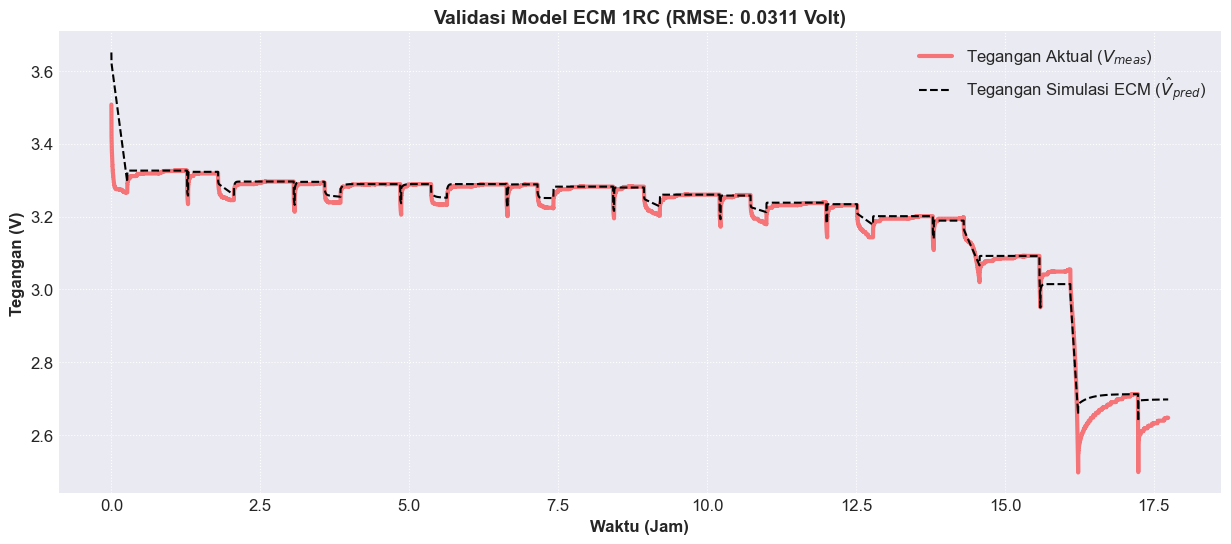

In [6]:
import warnings

# =========================================================
# SIMULASI ECM 1RC DENGAN LUT OCV & SAFEGUARD NUMERIK
# =========================================================
# 1. Standarisasi Satuan
Q_nominal_Ah = 22.0
Q_Coulomb = Q_nominal_Ah * 3600.0  # Konversi ke Ampere-detik

V_model = []
v_c1 = 0.0

print("⏳ Memulai simulasi model ECM 1RC...")

# Loop Simulasi
for i in range(len(df)):
    soc_k = np.clip(df['SOC_CC'].iloc[i], 0.0, 1.0)
    I_k = df['Cur(A)'].iloc[i]
    dt_k = df['dt'].iloc[i]
    
    # Ambil parameter ECM
    R0 = max(float(f_R0(soc_k)), 1e-4)
    R1 = max(float(f_R1(soc_k)), 1e-4)
    C1 = max(float(f_C1(soc_k)), 1.0)
    
    # PEMANGGILAN OCV MENGGUNAKAN LUT BARU
    OCV = float(f_OCV_LUT(soc_k))
    
    tau = R1 * C1
    if tau < 1e-6:
        tau = 1e-6
    
    # Diskretisasi Eksak ZOH
    if dt_k > 0:
        alpha = np.exp(-dt_k / tau)
        v_c1 = (alpha * v_c1) + (R1 * (1.0 - alpha) * I_k)
        
    # Kalkulasi Tegangan Terminal
    V_term = OCV - v_c1 - (I_k * R0)
    V_model.append(V_term)

df['V_ECM'] = V_model

# Membersihkan data dari NaN
df['V_ECM'] = df['V_ECM'].fillna(method='bfill')
rmse_ecm = np.sqrt(np.mean((df['Vol(V)'] - df['V_ECM'])**2))

plt.figure(figsize=(15, 6))
plt.plot(df['Time(S)']/3600, df['Vol(V)'], label='Tegangan Aktual ($V_{meas}$)', color='red', linewidth=3, alpha=0.5)
plt.plot(df['Time(S)']/3600, df['V_ECM'], label='Tegangan Simulasi ECM ($\hat{V}_{pred}$)', color='black', linestyle='--', linewidth=1.5)
plt.title(f'Validasi Model ECM 1RC (RMSE: {rmse_ecm:.4f} Volt)', fontweight='bold', fontsize=14)
plt.xlabel('Waktu (Jam)', fontweight='bold')
plt.ylabel('Tegangan (V)', fontweight='bold')
plt.legend(); plt.grid(True, linestyle=':')
plt.show()

---
## 7️⃣ IMPLEMENTASI EXTENDED KALMAN FILTER (EKF) TERSTABILISASI

**Perhitungan Jacobian Numerik ($H$) Tanpa Polinomial:**
Karena kita telah mengganti polinomial dengan Look-Up Table (LUT), matriks Jacobian (kemiringan kurva $\frac{\partial OCV}{\partial SOC}$) tidak bisa dihitung secara analitik. 
Sebagai gantinya, kita menggunakan pendekatan **Turunan Numerik Selisih Tengah (Central Difference)**:
$$\frac{d OCV}{d SOC} \approx \frac{f_{OCV\_LUT}(SOC + \Delta) - f_{OCV\_LUT}(SOC - \Delta)}{2 \cdot \Delta}$$
Dimana $\Delta$ adalah selisih kecil (misal $0.001$). 

**Safeguard EKF:** Untuk mencegah matriks $H$ bernilai nol di area *plateau* datar (yang dapat menyebabkan EKF buta terhadap koreksi tegangan), nilai turunan akan dibatasi minimum pada angka wajar positif (misal $0.001$).

⏳ Menjalankan algoritma Extended Kalman Filter...
✅ Selesai!


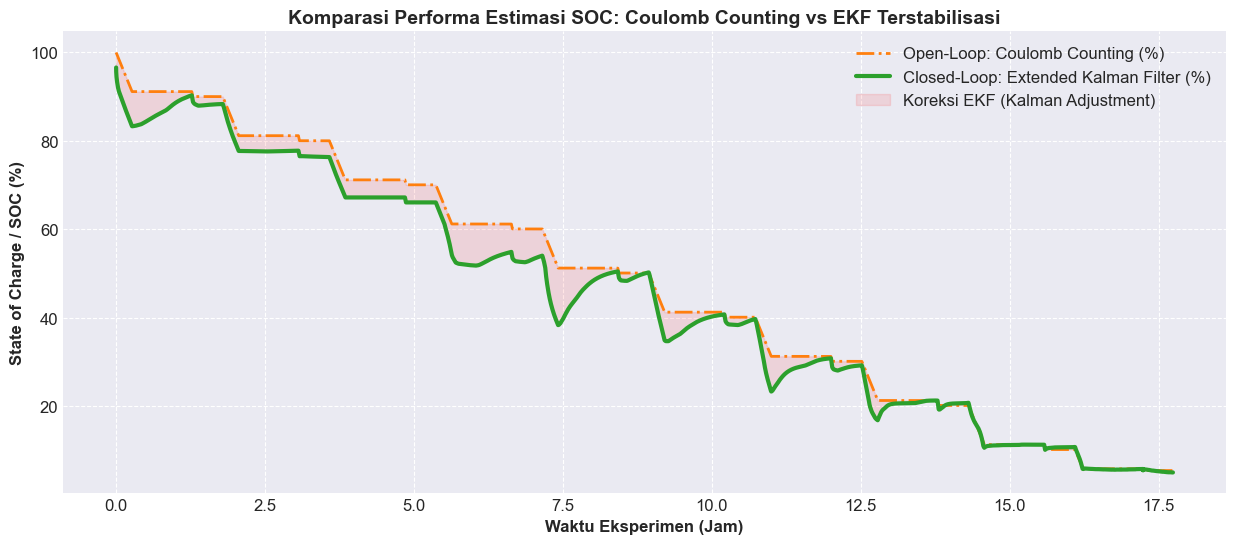

In [7]:
# =========================================================
# KELAS EXTENDED KALMAN FILTER DENGAN NUMERICAL JACOBIAN
# =========================================================
class LiFePO4_EKF:
    def __init__(self, Q_Coulomb, f_ocv):
        self.Q_c = Q_Coulomb  
        self.x = np.array([[1.0], [0.0]]) # State: [SOC=100%, Vc1=0V]
        self.P = np.array([[1e-2, 0], [0, 1e-2]])
        
        # Tuning Kalman Filter
        self.Q_noise = np.array([[1e-6, 0], [0, 1e-4]]) # Process Noise
        self.R_noise = np.array([[0.01]])               # Measurement Noise (UBAH DARI 0.1 JADI 0.01)
        
        # Simpan fungsi LUT
        self.f_ocv = f_ocv
        
    def get_dOCV_dSOC(self, soc_val):
        # Pendekatan Turunan Numerik Selisih Tengah (Central Difference)
        delta = 0.001
        
        # Pastikan tidak melewati batas ekstrapolasi bawah/atas
        s_high = min(soc_val + delta, 1.0)
        s_low = max(soc_val - delta, 0.0)
        
        # Evaluasi dari LUT
        ocv_high = float(self.f_ocv(s_high))
        ocv_low = float(self.f_ocv(s_low))
        
        derivative = (ocv_high - ocv_low) / (s_high - s_low)
        
        # Safeguard: Paksa dOCV_dSOC positif minimal 0.001 agar EKF tidak collapse di area plateau
        return max(float(derivative), 0.001)

    def step(self, I_meas, V_meas, dt):
        soc_prev = np.clip(float(self.x[0, 0]), 0.0, 1.0)
        vc1_prev = float(self.x[1, 0])
        
        # Evaluasi Parameter ECM
        R0 = max(float(f_R0(soc_prev)), 1e-4)
        R1 = max(float(f_R1(soc_prev)), 1e-4)
        C1 = max(float(f_C1(soc_prev)), 1.0)
        tau = R1 * C1
        
        # Panggil OCV dari LUT
        OCV = float(self.f_ocv(soc_prev))
        
        # Hitung Matriks Jacobian H (Turunan OCV)
        dOCV_dSOC = self.get_dOCV_dSOC(soc_prev)
        
        # =====================================
        # TAHAP 1: PREDICTION (A PRIORI)
        # =====================================
        soc_pred = soc_prev - (I_meas * dt / self.Q_c)
        soc_pred = np.clip(soc_pred, 0.0, 1.0)
        
        alpha = np.exp(-dt / tau) if dt > 0 else 1.0
        vc1_pred = (alpha * vc1_prev) + (R1 * (1.0 - alpha) * I_meas)
        
        self.x = np.array([[soc_pred], [vc1_pred]])
        
        A = np.array([[1.0, 0.0], [0.0, alpha]])
        self.P = A @ self.P @ A.T + self.Q_noise
        
        # =====================================
        # TAHAP 2: UPDATE (A POSTERIORI)
        # =====================================
        V_pred = OCV - vc1_pred - (I_meas * R0)
        H = np.array([[dOCV_dSOC, -1.0]])
        
        S = H @ self.P @ H.T + self.R_noise
        K = self.P @ H.T @ np.linalg.inv(S)
        
        error = V_meas - V_pred
        
        # Koreksi State akhir
        self.x = self.x + (K * error)
        self.x[0, 0] = np.clip(self.x[0, 0], 0.0, 1.0)
        
        self.P = (np.eye(2) - K @ H) @ self.P
        
        return float(self.x[0, 0])

# =========================================================
# EKSEKUSI EKF DAN VISUALISASI
# =========================================================
print("⏳ Menjalankan algoritma Extended Kalman Filter...")
# Inisialisasi EKF dengan mengirimkan Q_Coulomb dan fungsi LUT
ekf_filter = LiFePO4_EKF(Q_Coulomb=Q_Coulomb, f_ocv=f_OCV_LUT)
soc_ekf_history = []

for i in range(len(df)):
    soc_est = ekf_filter.step(df['Cur(A)'].iloc[i], df['Vol(V)'].iloc[i], df['dt'].iloc[i])
    soc_ekf_history.append(soc_est)

df['SOC_EKF'] = soc_ekf_history
print("✅ Selesai!")

# Plot Komparasi Akhir
plt.figure(figsize=(15, 6))
plt.plot(df['Time(S)']/3600, df['SOC_CC']*100, label='Open-Loop: Coulomb Counting (%)', color='tab:orange', linestyle='-.', linewidth=2)
plt.plot(df['Time(S)']/3600, df['SOC_EKF']*100, label='Closed-Loop: Extended Kalman Filter (%)', color='tab:green', linewidth=3)

plt.fill_between(df['Time(S)']/3600, df['SOC_CC']*100, df['SOC_EKF']*100, color='red', alpha=0.1, label='Koreksi EKF (Kalman Adjustment)')

plt.title('Komparasi Performa Estimasi SOC: Coulomb Counting vs EKF Terstabilisasi', fontweight='bold', fontsize=14)
plt.xlabel('Waktu Eksperimen (Jam)', fontweight='bold')
plt.ylabel('State of Charge / SOC (%)', fontweight='bold')
plt.legend(); plt.grid(True, linestyle='--')
plt.show()

---
## 8️⃣ VALIDASI NUMERIK DAN AUDIT ILMIAH (DATA EXPORT)

Tahap ini didedikasikan untuk melakukan *numerical check*, validasi statistik, dan ekstraksi parameter ke dalam bentuk tabel matriks yang siap digunakan untuk keperluan audit ilmiah eksternal. Tidak ada visualisasi grafik pada bagian ini guna memastikan efisiensi komputasi dan fokus pada presisi angka matematis murni.

### **A. Validasi Parameter ECM (R0, R1, C1, dan Tau)**
Tujuan: Memastikan hasil *curve fitting* pada fase relaksasi tidak melanggar batasan fisik baterai LiFePO4, yaitu:
1. Tidak ada resistansi atau kapasitansi bernilai negatif.
2. Konstanta waktu difusi ($\tau$) berada pada batas wajar (tidak terjadi singularitas komputasi di mana $\tau < 1$ detik).

In [8]:
import pandas as pd
import numpy as np

# =========================================================
# 1. VALIDASI PARAMETER ECM
# =========================================================
print("⏳ Menjalankan Validasi Parameter ECM...")

# Menghitung Konstanta Waktu Tau
df_params['Tau (s)'] = df_params['R1 (Ohm)'] * df_params['C1 (Farad)']

# Pengecekan stabilitas fisik
negative_check = (df_params[['R0 (Ohm)', 'R1 (Ohm)', 'C1 (Farad)', 'Tau (s)']] < 0).any().any()
tau_too_small = (df_params['Tau (s)'] < 1.0).any()

# Membuat Tabel Ringkasan Statistik
ecm_summary = pd.DataFrame({
    'Metric': ['Minimum', 'Maximum', 'Mean'],
    'R0 (Ohm)': [df_params['R0 (Ohm)'].min(), df_params['R0 (Ohm)'].max(), df_params['R0 (Ohm)'].mean()],
    'R1 (Ohm)': [df_params['R1 (Ohm)'].min(), df_params['R1 (Ohm)'].max(), df_params['R1 (Ohm)'].mean()],
    'C1 (Farad)': [df_params['C1 (Farad)'].min(), df_params['C1 (Farad)'].max(), df_params['C1 (Farad)'].mean()],
    'Tau (s)': [df_params['Tau (s)'].min(), df_params['Tau (s)'].max(), df_params['Tau (s)'].mean()]
})

# Simpan Tabel Utama ke CSV
df_params.to_csv("ECM_parameters_validation.csv", index=False)

print("✅ ECM_parameters_validation.csv berhasil disimpan.")
print("-" * 50)
print("RINGKASAN STATISTIK ECM:")
display(ecm_summary)
print(f"Apakah ada parameter negatif? : {'YA (CRITICAL ERROR)' if negative_check else 'TIDAK (AMAN)'}")
print(f"Apakah ada tau < 1 detik?     : {'YA (WARNING)' if tau_too_small else 'TIDAK (AMAN)'}")

⏳ Menjalankan Validasi Parameter ECM...
✅ ECM_parameters_validation.csv berhasil disimpan.
--------------------------------------------------
RINGKASAN STATISTIK ECM:


,Metric,R0 (Ohm),R1 (Ohm),C1 (Farad),Tau (s)
0,Minimum,0.002667,0.000500,7470.088797,10.000000
1,Maximum,0.003733,0.006979,100000.000000,697.892323
2,Mean,0.002907,0.001993,30324.524109,102.356799


Apakah ada parameter negatif? : TIDAK (AMAN)
Apakah ada tau < 1 detik?     : TIDAK (AMAN)


### **B. Validasi Model Tegangan (Voltage Model Validation)**
Tujuan: Mengukur performa kuantitatif dari model *State-Space* ECM 1RC terhadap data eksperimental asli (Sensor ZKETECH).
Metrik evaluasi yang dihitung meliputi:
* **RMSE** (*Root Mean Square Error*): Menghukum *error* atau penyimpangan yang besar (spike).
* **MAE** (*Mean Absolute Error*): Menunjukkan rata-rata *error* absolut secara umum.
* **MAPE** (*Mean Absolute Percentage Error*): Menunjukkan persentase penyimpangan secara relatif terhadap nilai asli.

In [9]:
# =========================================================
# 2. VALIDASI MODEL TEGANGAN
# =========================================================
print("\n⏳ Menjalankan Validasi Model Tegangan...")

# Membersihkan potensi nilai NaN atau Inf
valid_idx = ~df['Vol(V)'].isna() & ~df['V_ECM'].isna() & ~np.isinf(df['V_ECM'])

v_obs = df.loc[valid_idx, 'Vol(V)']
v_sim = df.loc[valid_idx, 'V_ECM']

# Perhitungan Metrik Akurasi
rmse_v = np.sqrt(np.mean((v_obs - v_sim)**2))
mae_v = np.mean(np.abs(v_obs - v_sim))
mape_v = np.mean(np.abs((v_obs - v_sim) / v_obs)) * 100

voltage_summary = pd.DataFrame({
    'Parameter': [
        'Tegangan Observasi Minimum (V)', 'Tegangan Observasi Maksimum (V)',
        'Tegangan Simulasi Minimum (V)', 'Tegangan Simulasi Maksimum (V)',
        'RMSE (V)', 'MAE (V)', 'MAPE (%)'
    ],
    'Value': [
        v_obs.min(), v_obs.max(),
        v_sim.min(), v_sim.max(),
        rmse_v, mae_v, mape_v
    ]
})

voltage_summary.to_csv("Voltage_Model_Validation.csv", index=False)

print("✅ Voltage_Model_Validation.csv berhasil disimpan.")
print("-" * 50)
display(voltage_summary)


⏳ Menjalankan Validasi Model Tegangan...
✅ Voltage_Model_Validation.csv berhasil disimpan.
--------------------------------------------------


,Parameter,Value
0,Tegangan Observasi Minimum (V),2.498000
1,Tegangan Observasi Maksimum (V),3.507000
2,Tegangan Simulasi Minimum (V),2.638719
3,Tegangan Simulasi Maksimum (V),3.650000
4,RMSE (V),0.031078
5,MAE (V),0.013840
6,MAPE (%),0.458736


### **C. Validasi Estimasi SOC (Coulomb Counting vs EKF)**
Tujuan: Memastikan algoritma *Extended Kalman Filter* (EKF) memberikan hasil estimasi SOC yang logis (berada di rentang 0% hingga 100%) dan membandingkan deviasinya terhadap *Open-Loop Coulomb Counting*.

In [10]:
# =========================================================
# 3. VALIDASI STATE OF CHARGE (SOC)
# =========================================================
print("\n⏳ Menjalankan Validasi SOC...")

# Ambil SOC dalam persentase
soc_cc = df['SOC_CC'] * 100
soc_ekf = df['SOC_EKF'] * 100

# Metrik deviasi antara EKF dan Coulomb Counting
soc_diff = np.abs(soc_cc - soc_ekf)
rmse_soc = np.sqrt(np.mean(soc_diff**2))
mae_soc = np.mean(soc_diff)
max_diff_soc = soc_diff.max()

soc_summary = pd.DataFrame({
    'Parameter': [
        'SOC CC Minimum (%)', 'SOC CC Maksimum (%)',
        'SOC EKF Minimum (%)', 'SOC EKF Maksimum (%)',
        'Selisih Maksimum CC vs EKF (%)',
        'RMSE SOC (%)', 'MAE SOC (%)'
    ],
    'Value': [
        soc_cc.min(), soc_cc.max(),
        soc_ekf.min(), soc_ekf.max(),
        max_diff_soc, rmse_soc, mae_soc
    ]
})

soc_summary.to_csv("SOC_Validation.csv", index=False)

print("✅ SOC_Validation.csv berhasil disimpan.")
print("-" * 50)
display(soc_summary)


⏳ Menjalankan Validasi SOC...
✅ SOC_Validation.csv berhasil disimpan.
--------------------------------------------------


,Parameter,Value
0,SOC CC Minimum (%),5.488725
1,SOC CC Maksimum (%),100.000000
2,SOC EKF Minimum (%),5.052777
3,SOC EKF Maksimum (%),96.605546
4,Selisih Maksimum CC vs EKF (%),12.901979
5,RMSE SOC (%),4.170813
6,MAE SOC (%),3.059581


### **D. Pengecekan Stabilitas Numerik (Numerical Stability Audit)**
Tujuan: Mencetak konfirmasi akhir (*sanity check*) dari variabel fundamental yang digunakan di dalam *looping State-Space* dan pembaruan EKF untuk membuktikan tidak ada kesalahan satuan (unit) yang dapat memicu ledakan matriks komputasi.

In [11]:
# =========================================================
# 4. CEK STABILITAS NUMERIK FINAL
# =========================================================
print("\n" + "="*50)
print("🛡️ HASIL AUDIT STABILITAS NUMERIK SISTEM")
print("="*50)

# 1. Cek dt
dt_min = df['dt'].min()
dt_max = df['dt'].max()
print(f"[WAKTU] dt minimum : {dt_min} detik")
print(f"[WAKTU] dt maksimum: {dt_max} detik")

# 2. Cek Satuan Kapasitas
print(f"[KAPASITAS] Q Nominal  : {Q_nominal_Ah} Ah")
print(f"[KAPASITAS] Q Coulomb  : {Q_Coulomb} Ampere-detik (C)")

# 3. Cek Parameter Fisik
all_r1_positive = (df_params['R1 (Ohm)'] > 0).all()
all_c1_positive = (df_params['C1 (Farad)'] > 0).all()
print(f"[FISIKA] Apakah semua R1 > 0? : {all_r1_positive}")
print(f"[FISIKA] Apakah semua C1 > 0? : {all_c1_positive}")

# 4. Cek Rentang Kewajaran Tau
tau_min = df_params['Tau (s)'].min()
tau_max = df_params['Tau (s)'].max()
is_tau_logical = (tau_min >= 10.0) and (tau_max <= 5000.0) # Toleransi wajar LiFePO4
print(f"[DIFUSI] Rentang Tau Aktual : {tau_min:.2f} s.d {tau_max:.2f} detik")
print(f"[DIFUSI] Apakah Tau masuk akal (10s - 5000s)? : {'YA' if is_tau_logical else 'TIDAK / WARNING'}")

print("="*50)
print("KONSISTENSI NUMERIK TERVALIDASI. DATA SIAP UNTUK AUDIT ILMIAH.")
print("="*50)


🛡️ HASIL AUDIT STABILITAS NUMERIK SISTEM
[WAKTU] dt minimum : 0.0 detik
[WAKTU] dt maksimum: 3.0 detik
[KAPASITAS] Q Nominal  : 22.0 Ah
[KAPASITAS] Q Coulomb  : 79200.0 Ampere-detik (C)
[FISIKA] Apakah semua R1 > 0? : True
[FISIKA] Apakah semua C1 > 0? : True
[DIFUSI] Rentang Tau Aktual : 10.00 s.d 697.89 detik
[DIFUSI] Apakah Tau masuk akal (10s - 5000s)? : YA
KONSISTENSI NUMERIK TERVALIDASI. DATA SIAP UNTUK AUDIT ILMIAH.
